In [1]:
from sympy import symbols, Eq, simplify, cos, sin, diff, solve,Matrix, pi,trigsimp,expand_trig
from sympy.physics.mechanics import dynamicsymbols,vlatex
import sympy.physics.mechanics.system as system
from sympy.printing.latex import LatexPrinter, print_latex

#from sympy.physics.vector import init_vprinting
#init_vprinting(pretty_print=True)
from misc_tools.print_latex import print_tex
print2 = lambda x: print_tex(vlatex(x))

input example : 
>>> arr_T = np.array([[r'\vec{v}_1', r'\vec{v}_2']]).T
>>> print_tex(arr_T,'=', np.arange(1,5).reshape(2,-1)/4, r'; symbols: \otimes, \cdot,\times')
output: 


<IPython.core.display.Math object>

https://courses.ece.ucsb.edu/ECE594/594D_W10Byl/hw/cartpole_eom.pdf

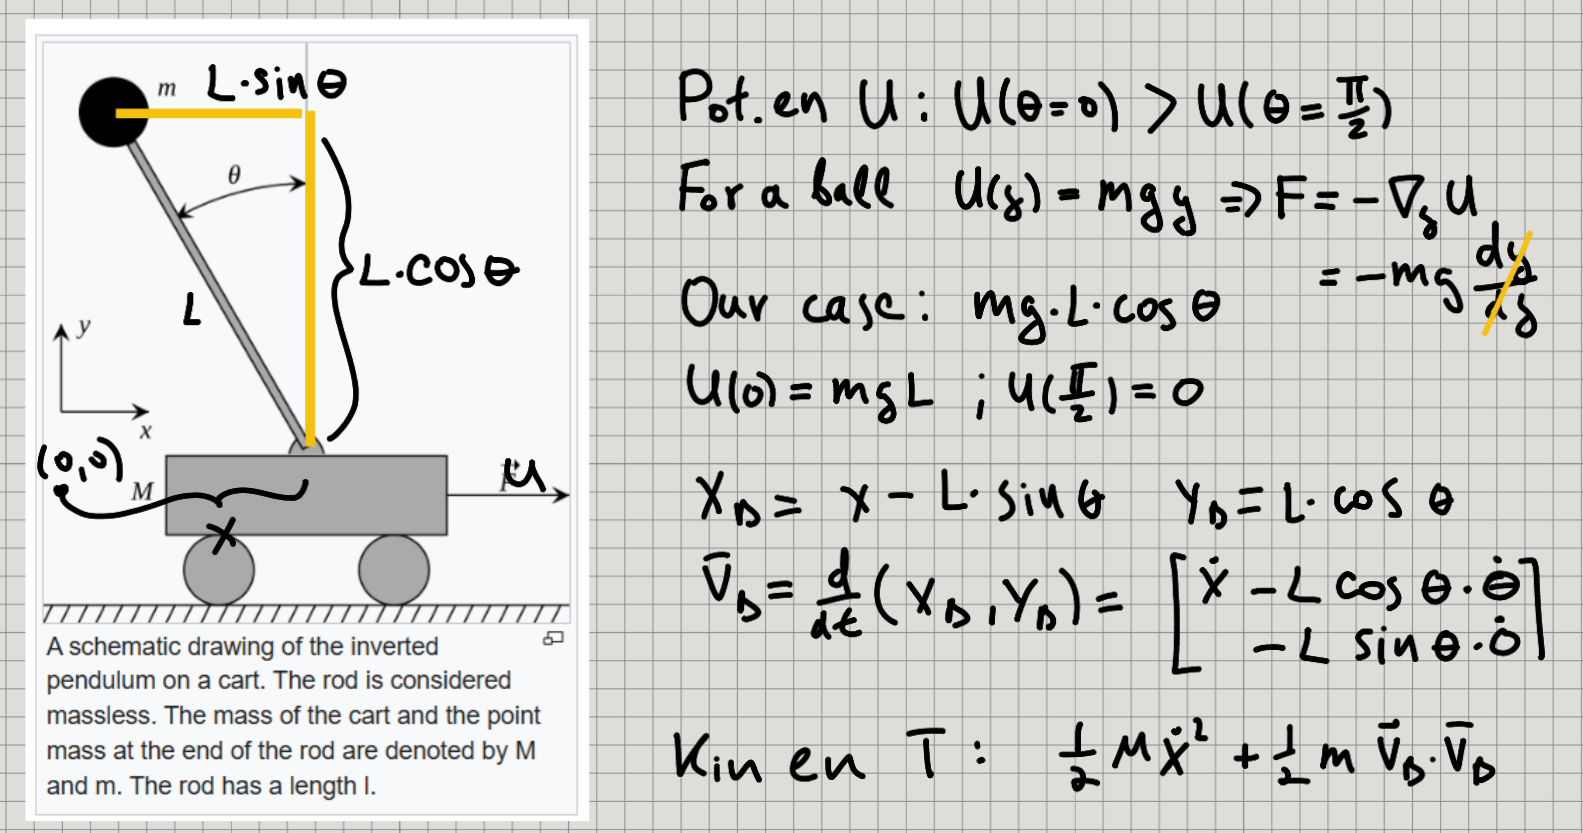

In [2]:
M,m,l,g,d,Tc,Tp   = symbols("M,m,l,g, delta,Tc,Tp", real=True, positive = True)
u, Up = symbols('u, U_p', real=True)
L = symbols(r'\mathcal{L}', real=True)
x,xp,yp,t   = dynamicsymbols('x,x_p,y_p,theta')
xd, td      = dynamicsymbols('x,theta', 1)
xdd, tdd    = dynamicsymbols('x,theta', 2)

### Cart Kinetic and potential energy

In [18]:
Tc = 0.5*M*xd**2
Uc = 0

### Pendulum kin and pot en

In [4]:
xp = x - l*sin(t)
yp = l*cos(t)
rp = Matrix([xp,yp])
print2(rp)
vp = diff(rp,'t')
print2(vp)
vp_mag2 = simplify(vp.dot(vp))
print2(vp_mag2)
Tp = 0.5*m*vp_mag2
print2(Tp)
Up = l*g*m*cos(t)
print2(Up)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
print2(Up.replace(t,0))
print2(Up.replace(t,pi/2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Lagrangian

Lagrangian = total kinetic energy -  total potential energy:
$$\mathcal{L} = T - U$$

In [6]:
Leq = Eq(L,((Tc+Tp)-(Uc+Up)).expand().collect(xd).simplify())
print2(Leq)
def get_eq(q, qdot):
    return simplify(diff(diff(Leq.rhs,qdot),'t')-diff(Leq.rhs,q))

<IPython.core.display.Math object>

### Eq for $\ddot x$

In [7]:
pde_x = Eq(get_eq(x,xd), u - d*xd)
print2(pde_x)
eqxdd_0 = Eq(xdd,solve(pde_x, xdd)[0])
print2(eqxdd_0)
#print(vlatex(eqxdd_0))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Eq for $\ddot \theta$

In [8]:
pde_t = Eq(get_eq(t,td),0)
print2(pde_t)
eqtdd_0 = Eq(tdd,solve(pde_t,tdd)[0])
print2(eqtdd_0)
print(vlatex(eqtdd_0))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

\ddot{\theta} = \frac{g \sin{\left(\theta \right)} + \cos{\left(\theta \right)} \ddot{x}}{l}


### Simplify, reduce powers

In [9]:
tdd_rhs = simplify(solve(eqtdd_0.replace(xdd, eqxdd_0.rhs), tdd)[0])
tdd_rhs = tdd_rhs.collect(g*sin(t)).collect(cos(t))
eqtdd = Eq(tdd,tdd_rhs)
print2(eqtdd)
print(vlatex(eqtdd))

<IPython.core.display.Math object>

\ddot{\theta} = \frac{g \left(M + m\right) \sin{\left(\theta \right)} - \frac{l m \sin{\left(2 \theta \right)} \dot{\theta}^{2}}{2} + \left(- \delta \dot{x} + u\right) \cos{\left(\theta \right)}}{l \left(M + m \sin^{2}{\left(\theta \right)}\right)}


In [10]:
tdd_rhs.subs([(t,pi/2), (x,0)]).simplify()

g/l

In [11]:
xdd_rhs = simplify(solve(eqxdd_0.replace(tdd, eqtdd_0.rhs), xdd)[0])
eqxdd = Eq(xdd,xdd_rhs)
print2(eqxdd)
print(vlatex(eqxdd))

<IPython.core.display.Math object>

\ddot{x} = \frac{- \delta \dot{x} + \frac{g m \sin{\left(2 \theta \right)}}{2} - l m \sin{\left(\theta \right)} \dot{\theta}^{2} + u}{M + m \sin^{2}{\left(\theta \right)}}


In [29]:
state = Matrix([x, xd, t, td, u])
sys = Matrix([xd, eqxdd.rhs, td, eqtdd.rhs])
A = sys.jacobian(state)
print("A = ")
print2(A)

A = 


<IPython.core.display.Math object>

Eval at fixed points

In [30]:
A_d = simplify(A.subs([ (xd, 0), (t, pi), (td, 0), (u,0)]))
A_u = simplify(A.subs([ (xd, 0), (t, 0 ), (td, 0), (u,0)]))
print("A (down pos) = ")
print2(A_d.simplify())
print("A (up pos) = ")
print2(A_u.simplify())

A (down pos) = 


<IPython.core.display.Math object>

A (up pos) = 


<IPython.core.display.Math object>

Added $u$ to system state to get derivative -> coefficient

So last column is for $u$

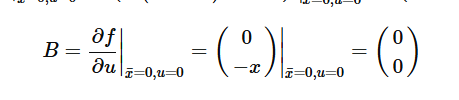

from

https://math.stackexchange.com/questions/2485861/how-to-calculate-a-and-b-matricies-in-control-theory-for-my-system-given-the-ode

In [28]:
A_u @ state

Matrix([
[                                                  Derivative(x(t), t)],
[                  -delta*Derivative(x(t), t)/M + g*m*theta(t)/M + u/M],
[                                                                    0],
[-delta*Derivative(x(t), t)/(M*l) + g*(M + m)*theta(t)/(M*l) + u/(M*l)]])

In [22]:
A_u[:,:-1] @ Matrix(state[:-1])

Matrix([
[                                        Derivative(x(t), t)],
[              -delta*Derivative(x(t), t)/M + g*m*theta(t)/M],
[                                                          0],
[-delta*Derivative(x(t), t)/(M*l) + g*(M + m)*theta(t)/(M*l)]])

In [23]:
A_u[:,-1] * state[-1]

Matrix([
[      0],
[    u/M],
[      0],
[u/(M*l)]])